In [1]:
import os
foldername = '/home/edavenport/analysis/vel-assim-manuscript/forecasts/results_figs/skill/'
os.makedirs(foldername, exist_ok=True)

In [3]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
import pandas as pd
import numpy as np
from forecasts.forecast_utils import get_forecast_params

# ═══════════════════════════════════════════════════════════════════
#  FORECAST PARAMETERS — only change start_date to switch forecasts
#  Supported range: Sep 2012 – Jul 2013 (1st of month)
# ═══════════════════════════════════════════════════════════════════
start_date = pd.Timestamp('2013-01-01')

# TPOSE-Vel state estimate directory (varies by run; set manually for each forecast)
vel_estimate_data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'

p = get_forecast_params(start_date)

# ── Unpack for use in subsequent cells ───────────────────────────
start_date  = p.start_date
end_date    = p.end_date
month_str   = p.month_str
day_str     = p.day_str
year_str    = p.year_str

noTAO_data_dir          = p.noTAO_data_dir
noTAO_forecast_data_dir = p.noTAO_forecast_data_dir
vel_forecast_data_dir   = p.vel_forecast_data_dir
grid_dir                = p.grid_dir

ref_date        = p.ref_date
itPerFile       = p.itPerFile
delta_t         = p.delta_t
num_diags       = p.num_diags
intervals       = p.intervals
n_forecast_days = p.n_forecast_days
n_eval          = p.n_eval
eval_slice      = p.eval_slice
eval_start_date = p.eval_start_date
days            = p.days
eval_dates      = p.eval_dates
eval_months     = p.eval_months
month_bounds    = p.month_bounds
month_centers   = p.month_centers

print(f'Forecast     : {start_date.date()} → {end_date.date()} ({n_forecast_days} days)')
print(f'itPerFile    : {itPerFile}  |  delta_t: {delta_t:.0f} s')
print(f'noTAO est dir: {noTAO_data_dir}')
print(f'noTAO fct dir: {noTAO_forecast_data_dir}')
print(f'Vel est dir  : {vel_estimate_data_dir}')
print(f'Vel fct dir  : {vel_forecast_data_dir}')

Forecast     : 2013-01-01 → 2013-04-30 (119 days)
itPerFile    : 72  |  delta_t: 1200 s
noTAO est dir: /data/SO3/averdy/TPOSE6/jan2013/diags_daily/
noTAO fct dir: /data/SO3/edavenport/tpose6/forecasts/jan012013_tpose_noVel/
Vel est dir  : /data/SO3/edavenport/tpose6/jan2013/run_iter14/
Vel fct dir  : /data/SO3/edavenport/tpose6/forecasts/jan012013/


### Load TPOSE Estimates and Forecasts

In [4]:
import matplotlib.pyplot as plt
import xarray as xr
from xmitgcm import open_mdsdataset
plt.rcParams['font.size'] = 14

prefix = ['diag_state']

def open_tpose(data_dir):
    ds = open_mdsdataset(
        data_dir=data_dir, grid_dir=grid_dir,
        iters=intervals, prefix=prefix, ref_date=ref_date, delta_t=delta_t)
    for coord in ['XC', 'YC', 'Z', 'XG', 'YG']:
        ds[coord] = ds[coord].astype(float)
    return ds

ds_tpose_noTAO          = open_tpose(noTAO_data_dir)
ds_tpose_noTAO_forecast = open_tpose(noTAO_forecast_data_dir)
ds_tpose_vel            = open_tpose(vel_estimate_data_dir)
ds_tpose_vel_forecast   = open_tpose(vel_forecast_data_dir)

### Load GLORYS Reanalysis

In [5]:
from forecasts.forecast_utils import load_hycom_daily

glorys = xr.open_mfdataset('/data/SO3/edavenport/tpose6/glorys_data/glorys_*.nc', combine='by_coords')
hycom  = load_hycom_daily(start_date, end_date)   # None if no files exist for this window

# Subset to evaluation window and equatorial band
glorys_wind = glorys[['uo', 'vo']].sel(
    time=slice(start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')),
    latitude=slice(-5, 5)
)
if hycom is not None:
    hycom_wind = hycom[['water_u', 'water_v']].sel(lat=slice(-5, 5))

if hycom is None:
    print('WARNING: No HYCOM data available for this forecast window — HYCOM will be omitted from figures.')

### Load and Daily-Average TAO ADCP Data

ADCP moorings used here are at the equator (lat=0) at 190°E (170°W), 220°E (140°W), and 250°E (110°W) —
the three sites that fall within the GLORYS domain. Hourly profiles are averaged to daily means. Fill value –9999 is masked as NaN.

In [6]:
adcp = xr.open_dataset('/data/SO3/edavenport/tpose6/tao_profiles/TAO_WO_2013_ADCP.nc')

# Parse dates
raw_dates = pd.to_datetime(
    adcp.prof_YYYYMMDD.values.astype(int).astype(str), format='%Y%m%d'
)

# Mask fill values
u_raw = adcp.prof_U.values.copy().astype(float)
v_raw = adcp.prof_V.values.copy().astype(float)
u_raw[u_raw == -9999.] = np.nan
v_raw[v_raw == -9999.] = np.nan

adcp_lons   = adcp.prof_lon.values     # per-profile longitudes
adcp_depths = adcp.prof_depth.values   # (62,) depth levels in meters

# Only the 3 equatorial ADCP sites within the GLORYS domain
tao_lons = np.array([190., 220., 250.])  # mooring longitudes (°E)

# Build daily-averaged arrays: (time, location, depth)
eval_dates = pd.date_range(start_date, periods=n_eval)
tao_u = np.full((n_eval, len(tao_lons), len(adcp_depths)), np.nan)
tao_v = np.full((n_eval, len(tao_lons), len(adcp_depths)), np.nan)

for i, d in enumerate(eval_dates):
    for j, lon in enumerate(tao_lons):
        mask = (raw_dates == d) & (adcp_lons == lon)
        if mask.sum() > 0:
            tao_u[i, j, :] = np.nanmean(u_raw[mask, :], axis=0)
            tao_v[i, j, :] = np.nanmean(v_raw[mask, :], axis=0)

print(f'TAO obs shape: {tao_u.shape}  (time, location, depth)')
print(f'Valid U obs (non-NaN): {np.sum(np.isfinite(tao_u))} / {tao_u.size}')
print(f'ADCP depth range: {adcp_depths[0]}–{adcp_depths[-1]} m')

TAO obs shape: (119, 3, 62)  (time, location, depth)
Valid U obs (non-NaN): 17350 / 22134
ADCP depth range: 10.0–315.0 m


/tmp/ipykernel_3599179/2399505786.py:29: RuntimeWarning: Mean of empty slice
  tao_u[i, j, :] = np.nanmean(u_raw[mask, :], axis=0)
/tmp/ipykernel_3599179/2399505786.py:30: RuntimeWarning: Mean of empty slice
  tao_v[i, j, :] = np.nanmean(v_raw[mask, :], axis=0)


### Interpolate Models to TAO Locations and Compute RMSE

TPOSE UVEL is on the XG (staggered-X) Arakawa-C grid; VVEL is on XC/YG.  
Both are interpolated to the ADCP mooring longitudes and depths (positive downward in metres).  
GLORYS uo/vo are on a regular –180:180 longitude grid; the TAO lons (190, 220, 250°E) are converted to –170, –140, –110 for interpolation.  

RMSE at each time step is the RMS across all valid (non-NaN) observation points (location × depth).

In [7]:
# Interpolation depths: match ADCP depth levels
interp_depths     = adcp_depths                # positive downward (m)
neg_interp_depths = -interp_depths             # TPOSE Z convention (negative)

# ── TPOSE extraction ─────────────────────────────────────────────────────────
def extract_tpose_vel(ds):
    """
    Interpolate UVEL and VVEL to TAO mooring locations and ADCP depths.
    Returns (u, v) each of shape (time, location, depth).
    """
    ds = ds.isel(time=eval_slice)

    loc_da   = xr.DataArray(tao_lons,          dims='location')
    depth_da = xr.DataArray(neg_interp_depths, dims='depth')

    u = (ds.UVEL
           .sel(YC=0.0, method='nearest')
           .interp(XG=loc_da, Z=depth_da, method='linear')
           .transpose('time', 'location', 'depth')
           .compute())

    v = (ds.VVEL
           .sel(YG=0.0, method='nearest')
           .interp(XC=loc_da, Z=depth_da, method='linear')
           .transpose('time', 'location', 'depth')
           .compute())

    return u.values, v.values

print('Extracting TPOSE-noVel state estimate...')
noTAO_u,     noTAO_v     = extract_tpose_vel(ds_tpose_noTAO)
print('Extracting TPOSE-noVel forecast...')
noTAO_fct_u, noTAO_fct_v = extract_tpose_vel(ds_tpose_noTAO_forecast)
print('Extracting TPOSE-Vel state estimate...')
vel_est_u,   vel_est_v   = extract_tpose_vel(ds_tpose_vel)
print('Extracting TPOSE-Vel forecast...')
vel_fct_u,   vel_fct_v   = extract_tpose_vel(ds_tpose_vel_forecast)
print('Done.')

# ── GLORYS extraction ─────────────────────────────────────────────────────────
# Convert TAO lons from 0–360 to −180:180 convention used by GLORYS and HYCOM
tao_lons_neg = tao_lons - 360            # [190, 220, 250] → [−170, −140, −110]
loc_da_g   = xr.DataArray(tao_lons_neg, dims='location')
depth_da_g = xr.DataArray(interp_depths, dims='depth')

glorys_u = (glorys_wind.uo
              .sel(latitude=0.0, method='nearest')
              .interp(longitude=loc_da_g, depth=depth_da_g, method='linear')
              .transpose('time', 'location', 'depth')
              .isel(time=eval_slice)
              .compute()).values

glorys_v = (glorys_wind.vo
              .sel(latitude=0.0, method='nearest')
              .interp(longitude=loc_da_g, depth=depth_da_g, method='linear')
              .transpose('time', 'location', 'depth')
              .isel(time=eval_slice)
              .compute()).values

print('GLORYS extracted. Shape:', glorys_u.shape)

# ── HYCOM extraction — skipped if no data for this window ────────────────────
if hycom is not None:
    loc_da_h   = xr.DataArray(tao_lons_neg, dims='location')
    depth_da_h = xr.DataArray(interp_depths, dims='depth')

    hycom_u = (hycom_wind.water_u
                 .sel(lat=0.0, method='nearest')
                 .interp(lon=loc_da_h, depth=depth_da_h, method='linear')
                 .transpose('time', 'location', 'depth')
                 .isel(time=eval_slice)
                 .compute()).values

    hycom_v = (hycom_wind.water_v
                 .sel(lat=0.0, method='nearest')
                 .interp(lon=loc_da_h, depth=depth_da_h, method='linear')
                 .transpose('time', 'location', 'depth')
                 .isel(time=eval_slice)
                 .compute()).values

    print('HYCOM extracted. Shape:', hycom_u.shape)

# ── RMSE functions ───────────────────────────────────────────────────────────
def point_rmse(model, obs):
    """RMS across valid obs points at each time step.
    model, obs: (time, location, depth)
    returns:    (time,)
    """
    diff = model - obs
    n_valid = np.sum(np.isfinite(diff), axis=(1, 2))
    return np.sqrt(np.nansum(diff**2, axis=(1, 2)) / n_valid)

def persistence_rmse(model_arr, obs_arr):
    """Use day-1 model field as constant forecast."""
    field = model_arr[0:1, :, :]
    return point_rmse(np.broadcast_to(field, model_arr.shape), obs_arr)

# ── Compute all RMSEs ─────────────────────────────────────────────────────────
rmse_noTAO_u          = point_rmse(noTAO_u,     tao_u)
rmse_noTAO_fct_u      = point_rmse(noTAO_fct_u, tao_u)
rmse_vel_est_u        = point_rmse(vel_est_u,   tao_u)
rmse_vel_fct_u        = point_rmse(vel_fct_u,   tao_u)
rmse_glorys_u         = point_rmse(glorys_u,    tao_u)
rmse_noTAO_fct_pers_u = persistence_rmse(noTAO_fct_u, tao_u)
rmse_vel_fct_pers_u   = persistence_rmse(vel_fct_u,   tao_u)

rmse_noTAO_v          = point_rmse(noTAO_v,     tao_v)
rmse_noTAO_fct_v      = point_rmse(noTAO_fct_v, tao_v)
rmse_vel_est_v        = point_rmse(vel_est_v,   tao_v)
rmse_vel_fct_v        = point_rmse(vel_fct_v,   tao_v)
rmse_glorys_v         = point_rmse(glorys_v,    tao_v)
rmse_noTAO_fct_pers_v = persistence_rmse(noTAO_fct_v, tao_v)
rmse_vel_fct_pers_v   = persistence_rmse(vel_fct_v,   tao_v)

if hycom is not None:
    rmse_hycom_u = point_rmse(hycom_u, tao_u)
    rmse_hycom_v = point_rmse(hycom_v, tao_v)

Extracting TPOSE-noVel state estimate...
Extracting TPOSE-noVel forecast...
Extracting TPOSE-Vel state estimate...
Extracting TPOSE-Vel forecast...
Done.
GLORYS extracted. Shape: (119, 3, 62)
HYCOM extracted. Shape: (119, 3, 62)


### Figure: Velocity RMSE vs TAO ADCP

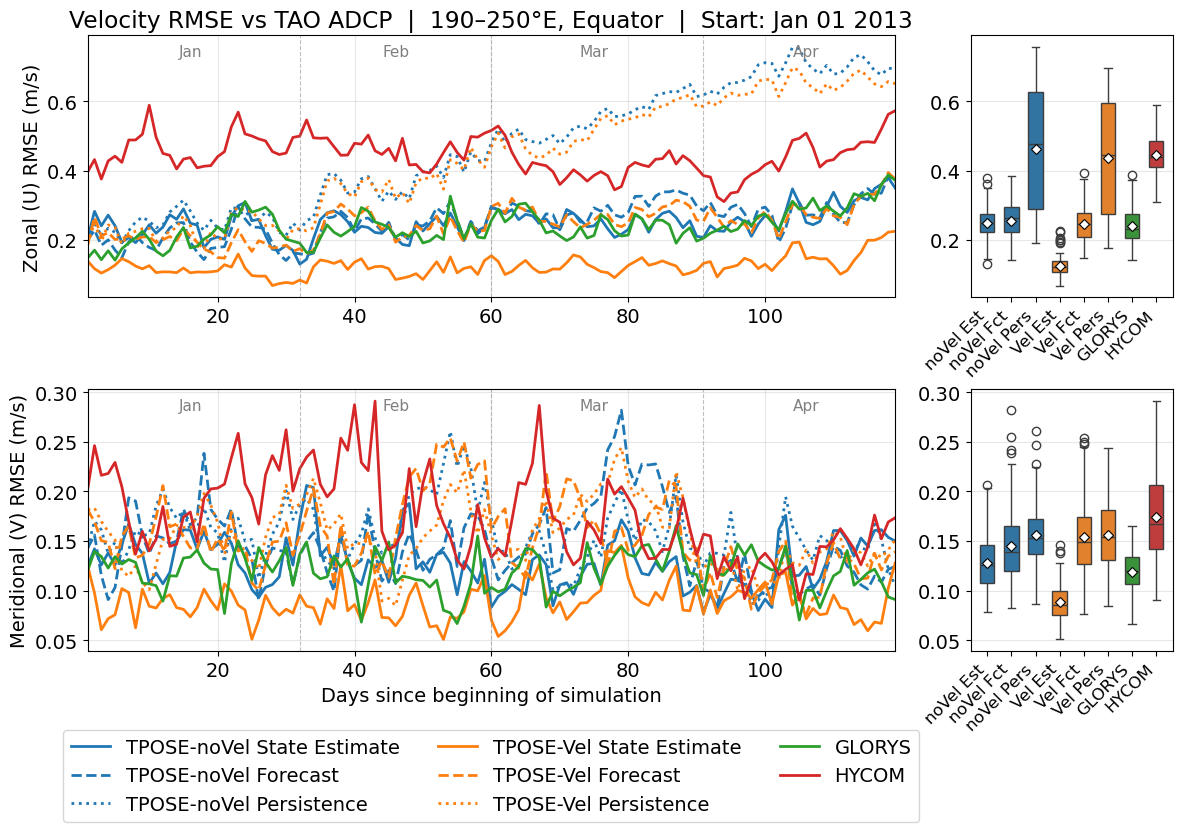

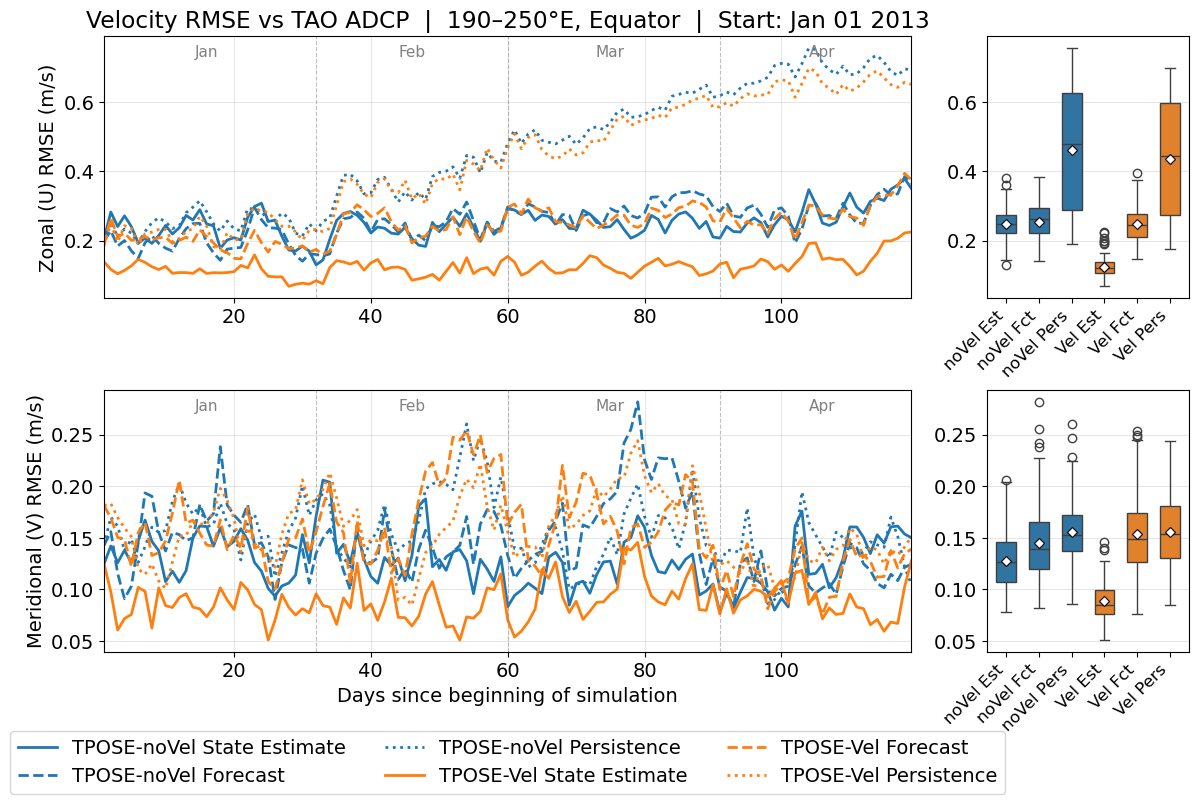

In [8]:
import seaborn as sns
import matplotlib.gridspec as gridspec

# Each entry: (u_data, v_data, long_label, short_label, color, linestyle)
datasets_all = [
    (rmse_noTAO_u,          rmse_noTAO_v,          'TPOSE-noVel State Estimate', 'noVel Est',  'C0', '-'),
    (rmse_noTAO_fct_u,      rmse_noTAO_fct_v,      'TPOSE-noVel Forecast',       'noVel Fct',  'C0', '--'),
    (rmse_noTAO_fct_pers_u, rmse_noTAO_fct_pers_v, 'TPOSE-noVel Persistence',    'noVel Pers', 'C0', ':'),
    (rmse_vel_est_u,        rmse_vel_est_v,         'TPOSE-Vel State Estimate',   'Vel Est',    'C1', '-'),
    (rmse_vel_fct_u,        rmse_vel_fct_v,         'TPOSE-Vel Forecast',         'Vel Fct',    'C1', '--'),
    (rmse_vel_fct_pers_u,   rmse_vel_fct_pers_v,    'TPOSE-Vel Persistence',      'Vel Pers',   'C1', ':'),
    (rmse_glorys_u,         rmse_glorys_v,           'GLORYS',                     'GLORYS',     'C2', '-'),
]
if hycom is not None:
    datasets_all.append((rmse_hycom_u, rmse_hycom_v, 'HYCOM', 'HYCOM', 'C3', '-'))

datasets_tpose = datasets_all[:6]

for datasets, suffix in [(datasets_all, ''), (datasets_tpose, '_tpose_only')]:
    short_names = [ds[3] for ds in datasets]
    palette     = [ds[4] for ds in datasets]

    fig = plt.figure(figsize=(14, 8))
    gs  = gridspec.GridSpec(2, 2, width_ratios=[4, 1], hspace=0.35, wspace=0.15)
    ax_ts  = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0])]
    ax_box = [fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 1])]
    ax_ts[1].sharex(ax_ts[0])

    for ax, ax_b, ylabel, uv in zip(
        ax_ts, ax_box,
        ['Zonal (U) RMSE (m/s)', 'Meridional (V) RMSE (m/s)'],
        [0, 1]
    ):
        ts_data = [ds[uv] for ds in datasets]

        # ── Time series ───────────────────────────────────────────
        for data, ds in zip(ts_data, datasets):
            ax.plot(days, data, color=ds[4], lw=2, ls=ds[5], label=ds[2])

        for d in month_bounds.values():
            ax.axvline(d, color='gray', lw=0.8, linestyle='--', alpha=0.5)
        ymax = ax.get_ylim()[1]
        for mname, xpos in month_centers:
            ax.text(xpos, ymax * 0.97, mname, ha='center', va='top', color='gray', fontsize=11)
        ax.set_ylabel(ylabel)
        ax.set_xlim(days[0], days[-1])
        ax.grid(alpha=0.3)

        # ── IQR summary column ────────────────────────────────────
        col_names = [f'ds{k}' for k in range(len(ts_data))]
        box_df    = pd.DataFrame({n: pd.Series(d) for n, d in zip(col_names, ts_data)})
        pal_dict  = dict(zip(col_names, palette))
        sns.boxplot(data=box_df, ax=ax_b, palette=pal_dict, width=0.6)
        for k, d in enumerate(ts_data):
            ax_b.plot(k, np.nanmean(d), marker='D', ms=5, color='white', mec='black', mew=0.8, zorder=5)
        ax_b.set_xticks(range(len(short_names)))
        ax_b.set_xticklabels(short_names, fontsize=12, rotation=45, ha='right')
        ax_b.set_ylabel('')
        ax_b.grid(alpha=0.3, axis='y')

    ax_ts[0].set_title(
        f'Velocity RMSE vs TAO ADCP  |  190–250°E, Equator  |  Start: {start_date.strftime("%b %d %Y")}'
    )
    ax_ts[1].set_xlabel('Days since beginning of simulation')

    # matplotlib fills legends column-major (top→bottom within each column), so with ncol=3
    # the handle order [noVel×3, Vel×3, others] naturally groups each set into its own column.
    ax_ts[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=3, borderaxespad=0)

    plt.savefig(foldername + f'vel_rmse_vs_tao_{month_str}{day_str}{year_str}{suffix}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

### Forecast Skill: Correlation vs TAO ADCP

Pearson correlation between each model's velocity profile and the TAO observations at each time step, computed across all valid (location × depth) points.

In [9]:
def profile_corr(model, obs):
    """Pearson r between model and obs at each time step.
    Flattens (location, depth) at each t and uses only points
    where both model and obs are finite.
    model, obs: (time, location, depth)
    returns:    (time,)
    """
    n_time = model.shape[0]
    r = np.full(n_time, np.nan)
    for t in range(n_time):
        m = model[t].ravel()
        o = obs[t].ravel()
        valid = np.isfinite(m) & np.isfinite(o)
        if valid.sum() > 1:
            r[t] = np.corrcoef(m[valid], o[valid])[0, 1]
    return r

def persistence_corr(model_arr, obs_arr):
    """Correlation using day-1 model field held constant."""
    field = np.broadcast_to(model_arr[0:1, :, :], model_arr.shape)
    return profile_corr(field, obs_arr)

# ── Zonal (U) ────────────────────────────────────────────────────────────────
corr_noTAO_u          = profile_corr(noTAO_u,     tao_u)
corr_noTAO_fct_u      = profile_corr(noTAO_fct_u, tao_u)
corr_vel_est_u        = profile_corr(vel_est_u,   tao_u)
corr_vel_fct_u        = profile_corr(vel_fct_u,   tao_u)
corr_glorys_u         = profile_corr(glorys_u,    tao_u)
corr_noTAO_fct_pers_u = persistence_corr(noTAO_fct_u, tao_u)
corr_vel_fct_pers_u   = persistence_corr(vel_fct_u,   tao_u)

# ── Meridional (V) ───────────────────────────────────────────────────────────
corr_noTAO_v          = profile_corr(noTAO_v,     tao_v)
corr_noTAO_fct_v      = profile_corr(noTAO_fct_v, tao_v)
corr_vel_est_v        = profile_corr(vel_est_v,   tao_v)
corr_vel_fct_v        = profile_corr(vel_fct_v,   tao_v)
corr_glorys_v         = profile_corr(glorys_v,    tao_v)
corr_noTAO_fct_pers_v = persistence_corr(noTAO_fct_v, tao_v)
corr_vel_fct_pers_v   = persistence_corr(vel_fct_v,   tao_v)

if hycom is not None:
    corr_hycom_u = profile_corr(hycom_u, tao_u)
    corr_hycom_v = profile_corr(hycom_v, tao_v)

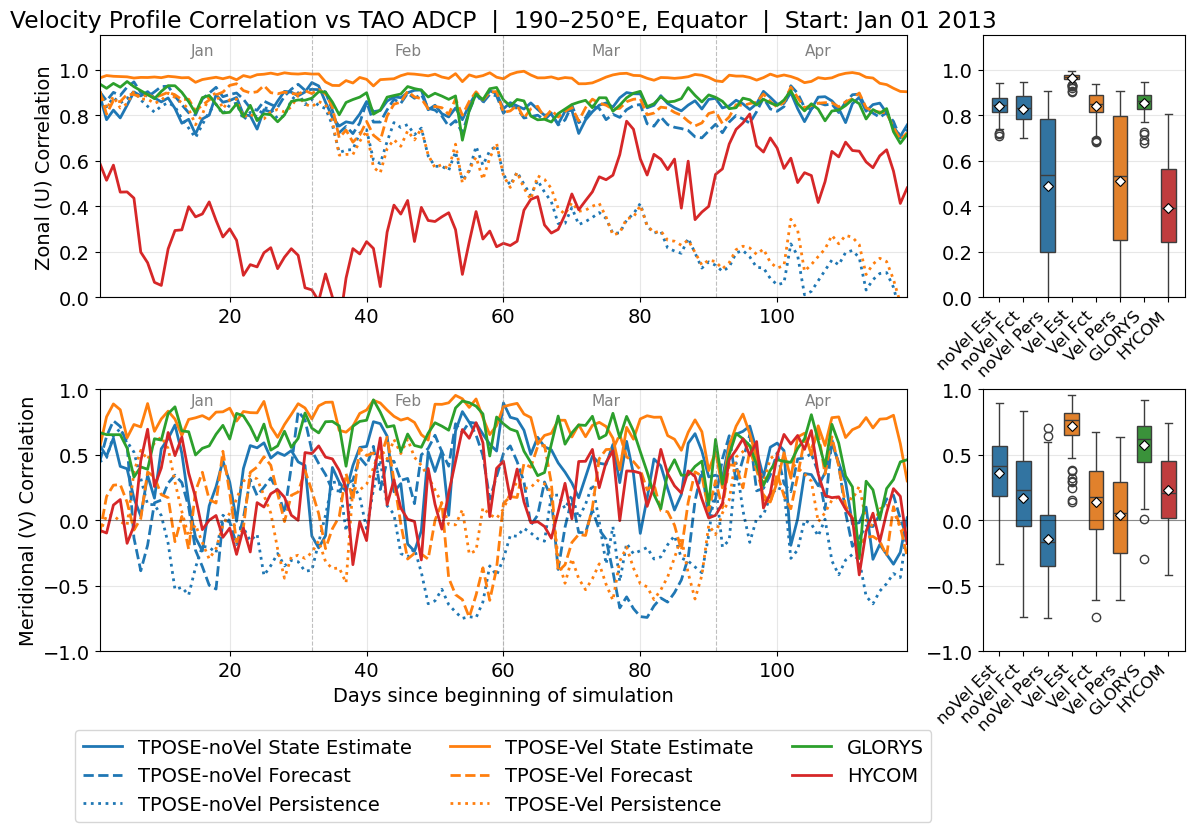

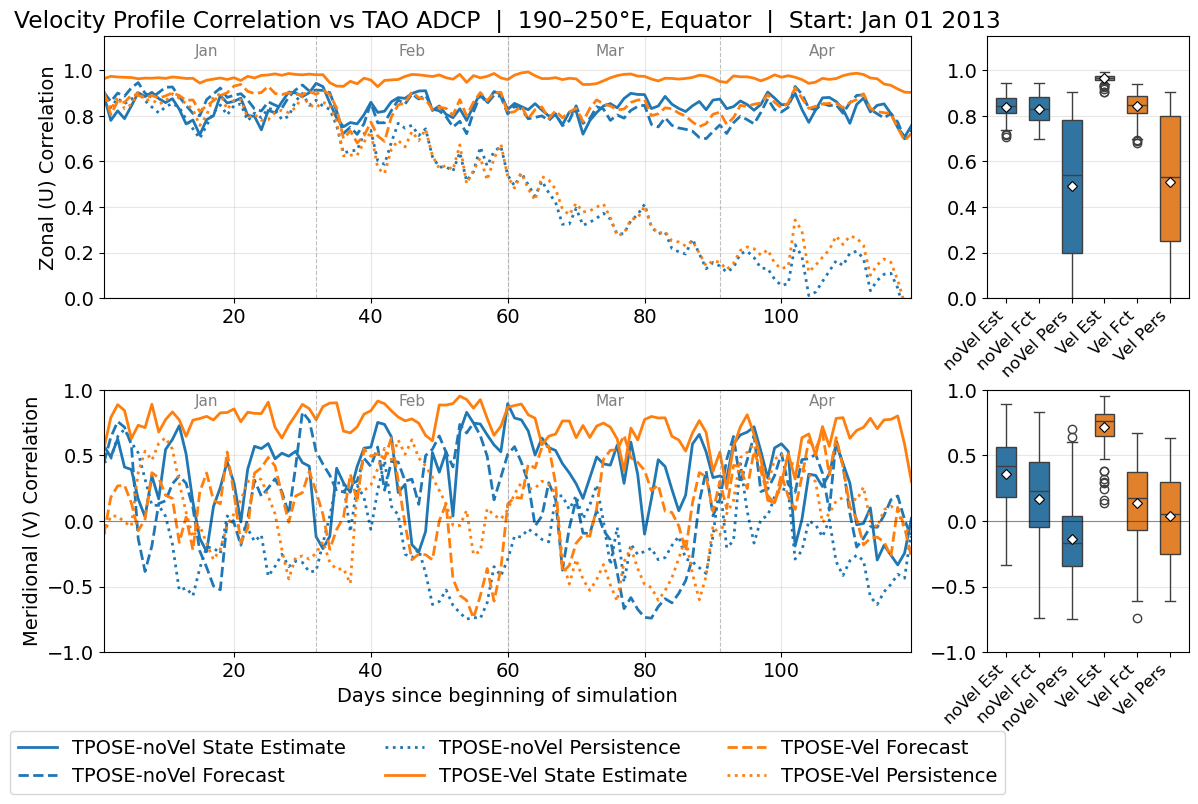

In [10]:
ylims = [(0, 1.15), (-1, 1)]

# Each entry: (u_data, v_data, long_label, short_label, color, linestyle)
datasets_all = [
    (corr_noTAO_u,          corr_noTAO_v,          'TPOSE-noVel State Estimate', 'noVel Est',  'C0', '-'),
    (corr_noTAO_fct_u,      corr_noTAO_fct_v,      'TPOSE-noVel Forecast',       'noVel Fct',  'C0', '--'),
    (corr_noTAO_fct_pers_u, corr_noTAO_fct_pers_v, 'TPOSE-noVel Persistence',    'noVel Pers', 'C0', ':'),
    (corr_vel_est_u,        corr_vel_est_v,         'TPOSE-Vel State Estimate',   'Vel Est',    'C1', '-'),
    (corr_vel_fct_u,        corr_vel_fct_v,         'TPOSE-Vel Forecast',         'Vel Fct',    'C1', '--'),
    (corr_vel_fct_pers_u,   corr_vel_fct_pers_v,    'TPOSE-Vel Persistence',      'Vel Pers',   'C1', ':'),
    (corr_glorys_u,         corr_glorys_v,           'GLORYS',                     'GLORYS',     'C2', '-'),
]
if hycom is not None:
    datasets_all.append((corr_hycom_u, corr_hycom_v, 'HYCOM', 'HYCOM', 'C3', '-'))

datasets_tpose = datasets_all[:6]

for datasets, suffix in [(datasets_all, ''), (datasets_tpose, '_tpose_only')]:
    short_names = [ds[3] for ds in datasets]
    palette     = [ds[4] for ds in datasets]

    fig = plt.figure(figsize=(14, 8))
    gs  = gridspec.GridSpec(2, 2, width_ratios=[4, 1], hspace=0.35, wspace=0.15)
    ax_ts  = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0])]
    ax_box = [fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 1])]
    ax_ts[1].sharex(ax_ts[0])

    for ax, ax_b, ylabel, ylim, uv in zip(
        ax_ts, ax_box,
        ['Zonal (U) Correlation', 'Meridional (V) Correlation'],
        ylims,
        [0, 1]
    ):
        ts_data = [ds[uv] for ds in datasets]

        # ── Time series ───────────────────────────────────────────
        for data, ds in zip(ts_data, datasets):
            ax.plot(days, data, color=ds[4], lw=2, ls=ds[5], label=ds[2])

        ax.axhline(0, color='k', lw=0.8, ls='-', alpha=0.4)

        for d in month_bounds.values():
            ax.axvline(d, color='gray', lw=0.8, linestyle='--', alpha=0.5)
        for mname, xpos in month_centers:
            ax.text(xpos, ylim[1] * 0.97, mname, ha='center', va='top', color='gray', fontsize=11)
        ax.set_ylabel(ylabel)
        ax.set_xlim(days[0], days[-1])
        ax.set_ylim(ylim)
        ax.grid(alpha=0.3)

        # ── IQR summary column ────────────────────────────────────
        col_names = [f'ds{k}' for k in range(len(ts_data))]
        box_df    = pd.DataFrame({n: pd.Series(d) for n, d in zip(col_names, ts_data)})
        pal_dict  = dict(zip(col_names, palette))
        sns.boxplot(data=box_df, ax=ax_b, palette=pal_dict, width=0.6)
        for k, d in enumerate(ts_data):
            ax_b.plot(k, np.nanmean(d), marker='D', ms=5, color='white', mec='black', mew=0.8, zorder=5)
        ax_b.axhline(0, color='k', lw=0.8, ls='-', alpha=0.4)
        ax_b.set_xticks(range(len(short_names)))
        ax_b.set_xticklabels(short_names, fontsize=12, rotation=45, ha='right')
        ax_b.set_ylabel('')
        ax_b.set_ylim(ylim)
        ax_b.grid(alpha=0.3, axis='y')

    ax_ts[0].set_title(
        f'Velocity Profile Correlation vs TAO ADCP  |  190–250°E, Equator  |  Start: {start_date.strftime("%b %d %Y")}'
    )
    ax_ts[1].set_xlabel('Days since beginning of simulation')

    # matplotlib fills legends column-major (top→bottom within each column), so with ncol=3
    # the handle order [noVel×3, Vel×3, others] naturally groups each set into its own column.
    ax_ts[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=3, borderaxespad=0)

    plt.savefig(foldername + f'vel_corr_vs_tao_{month_str}{day_str}{year_str}{suffix}.png',
                dpi=150, bbox_inches='tight')
    plt.show()